In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd

from src.gram_matrix import compute_gram_matrix
from src.pair_strat import get_offdiag, make_pairs_df, stratify_pairs, NEAR_MAX, MODERATE_MAX
from src.eda import run_eda
from src.clusters import ANTISOCIAL_CLUSTER, trait_cluster, pair_cluster_status


In [2]:
import torch

LAYER = 16
VEC_DIR = pathlib.Path("../results/anthropic_repl/persona_vectors/Llama-3.1-8B-Instruct")

KEEPER_TRAITS = [
    "apathetic", "confidence", "evil", "formality",
    "hallucinating", "humorous", "impolite", "power_seeking", "sycophantic",
]

raw_vecs, raw_norms = [], []
for trait in KEEPER_TRAITS:
    stack = torch.load(VEC_DIR / f"{trait}_response_avg_diff.pt", map_location="cpu")  # [33, 4096]
    v = stack[LAYER].numpy()
    raw_norms.append(np.linalg.norm(v))
    raw_vecs.append(v)

V_raw = np.stack(raw_vecs)                                      # [9, 4096]
behavior_vecs = V_raw / np.linalg.norm(V_raw, axis=1, keepdims=True)  # unit-norm for cosine
behaviors = KEEPER_TRAITS

print("raw norms:", {t: round(n, 3) for t, n in zip(KEEPER_TRAITS, raw_norms)})


raw norms: {'apathetic': 3.234, 'confidence': 1.339, 'evil': 2.931, 'formality': 2.028, 'hallucinating': 3.436, 'humorous': 2.792, 'impolite': 2.164, 'power_seeking': 2.011, 'sycophantic': 2.593}


In [3]:
behavior_matrix = behavior_vecs.shape
print(f"Behavior matrix shape: {behavior_matrix}")

vec_shape = behavior_vecs.shape[0]
print(f"Number of vectors is N = {vec_shape}")

expected_shape = (9, 4096)

G = compute_gram_matrix(behavior_vecs, expected_shape)  # compute gram matrix
print(f"Gram matrix shape is {G.shape}")


Behavior matrix shape: (9, 4096)
Number of vectors is N = 9
Gram matrix shape is (9, 9)


In [4]:
pairs_df = make_pairs_df(G, behaviors)  # get pairs dataframe
pairs_df.head(n=40)

,i,j,behavior_i,behavior_j,cosine,abs_cosine,stratum,trait_i_cluster,trait_j_cluster,pair_cluster_status,both_antisocial
0,0,1,apathetic,confidence,0.027274,0.027274,near,antisocial,other,cross_cluster,False
1,0,2,apathetic,evil,0.281318,0.281318,moderate,antisocial,antisocial,within_antisocial,True
2,0,3,apathetic,formality,-0.004033,0.004033,near,antisocial,other,cross_cluster,False
3,0,4,apathetic,hallucinating,-0.141053,0.141053,near,antisocial,other,cross_cluster,False
4,0,5,apathetic,humorous,0.212581,0.212581,moderate,antisocial,antisocial,within_antisocial,True
5,0,6,apathetic,impolite,0.715253,0.715253,high,antisocial,antisocial,within_antisocial,True
6,0,7,apathetic,power_seeking,0.026636,0.026636,near,antisocial,antisocial,within_antisocial,True
7,0,8,apathetic,sycophantic,0.071865,0.071865,near,antisocial,antisocial,within_antisocial,True
8,1,2,confidence,evil,0.214139,0.214139,moderate,other,antisocial,cross_cluster,False
9,1,3,confidence,formality,0.205315,0.205315,moderate,other,other,within_other,False


In [5]:
strat_df = stratify_pairs(pairs_df)
strat_df.head(n=40)

,i,j,behavior_i,behavior_j,cosine,abs_cosine,stratum,trait_i_cluster,trait_j_cluster,pair_cluster_status,both_antisocial
0,0,1,apathetic,confidence,0.027274,0.027274,near,antisocial,other,cross_cluster,False
1,0,3,apathetic,formality,-0.004033,0.004033,near,antisocial,other,cross_cluster,False
2,0,4,apathetic,hallucinating,-0.141053,0.141053,near,antisocial,other,cross_cluster,False
3,0,7,apathetic,power_seeking,0.026636,0.026636,near,antisocial,antisocial,within_antisocial,True
4,0,8,apathetic,sycophantic,0.071865,0.071865,near,antisocial,antisocial,within_antisocial,True
5,1,5,confidence,humorous,-0.070062,0.070062,near,other,antisocial,cross_cluster,False
6,1,6,confidence,impolite,0.143041,0.143041,near,other,antisocial,cross_cluster,False
7,2,3,evil,formality,-0.106873,0.106873,near,antisocial,other,cross_cluster,False
8,3,4,formality,hallucinating,0.123532,0.123532,near,other,other,within_other,False
9,3,7,formality,power_seeking,0.180232,0.180232,near,other,antisocial,cross_cluster,False


=== Summary statistics (all pairs) ===
                         value
n_pairs              36.000000
mean                  0.160308
std                   0.227492
min                  -0.496098
max                   0.715253
mean_abs              0.228669
std_abs               0.156211
near (<0.2)          16.000000
moderate [0.2,0.35)  13.000000
high (>=0.35)         7.000000

=== Most similar pairs ===
behavior_i    behavior_j    cosine  abs_cosine
 apathetic      impolite  0.715253    0.715253
 formality      humorous -0.496098    0.496098
      evil power_seeking  0.473241    0.473241
  humorous      impolite  0.435416    0.435416
      evil      impolite  0.398614    0.398614

=== Most orthogonal pairs ===
   behavior_i    behavior_j    cosine  abs_cosine
    apathetic     formality -0.004033    0.004033
    apathetic power_seeking  0.026636    0.026636
    apathetic    confidence  0.027274    0.027274
hallucinating      impolite -0.062659    0.062659
     humorous power_seeking  

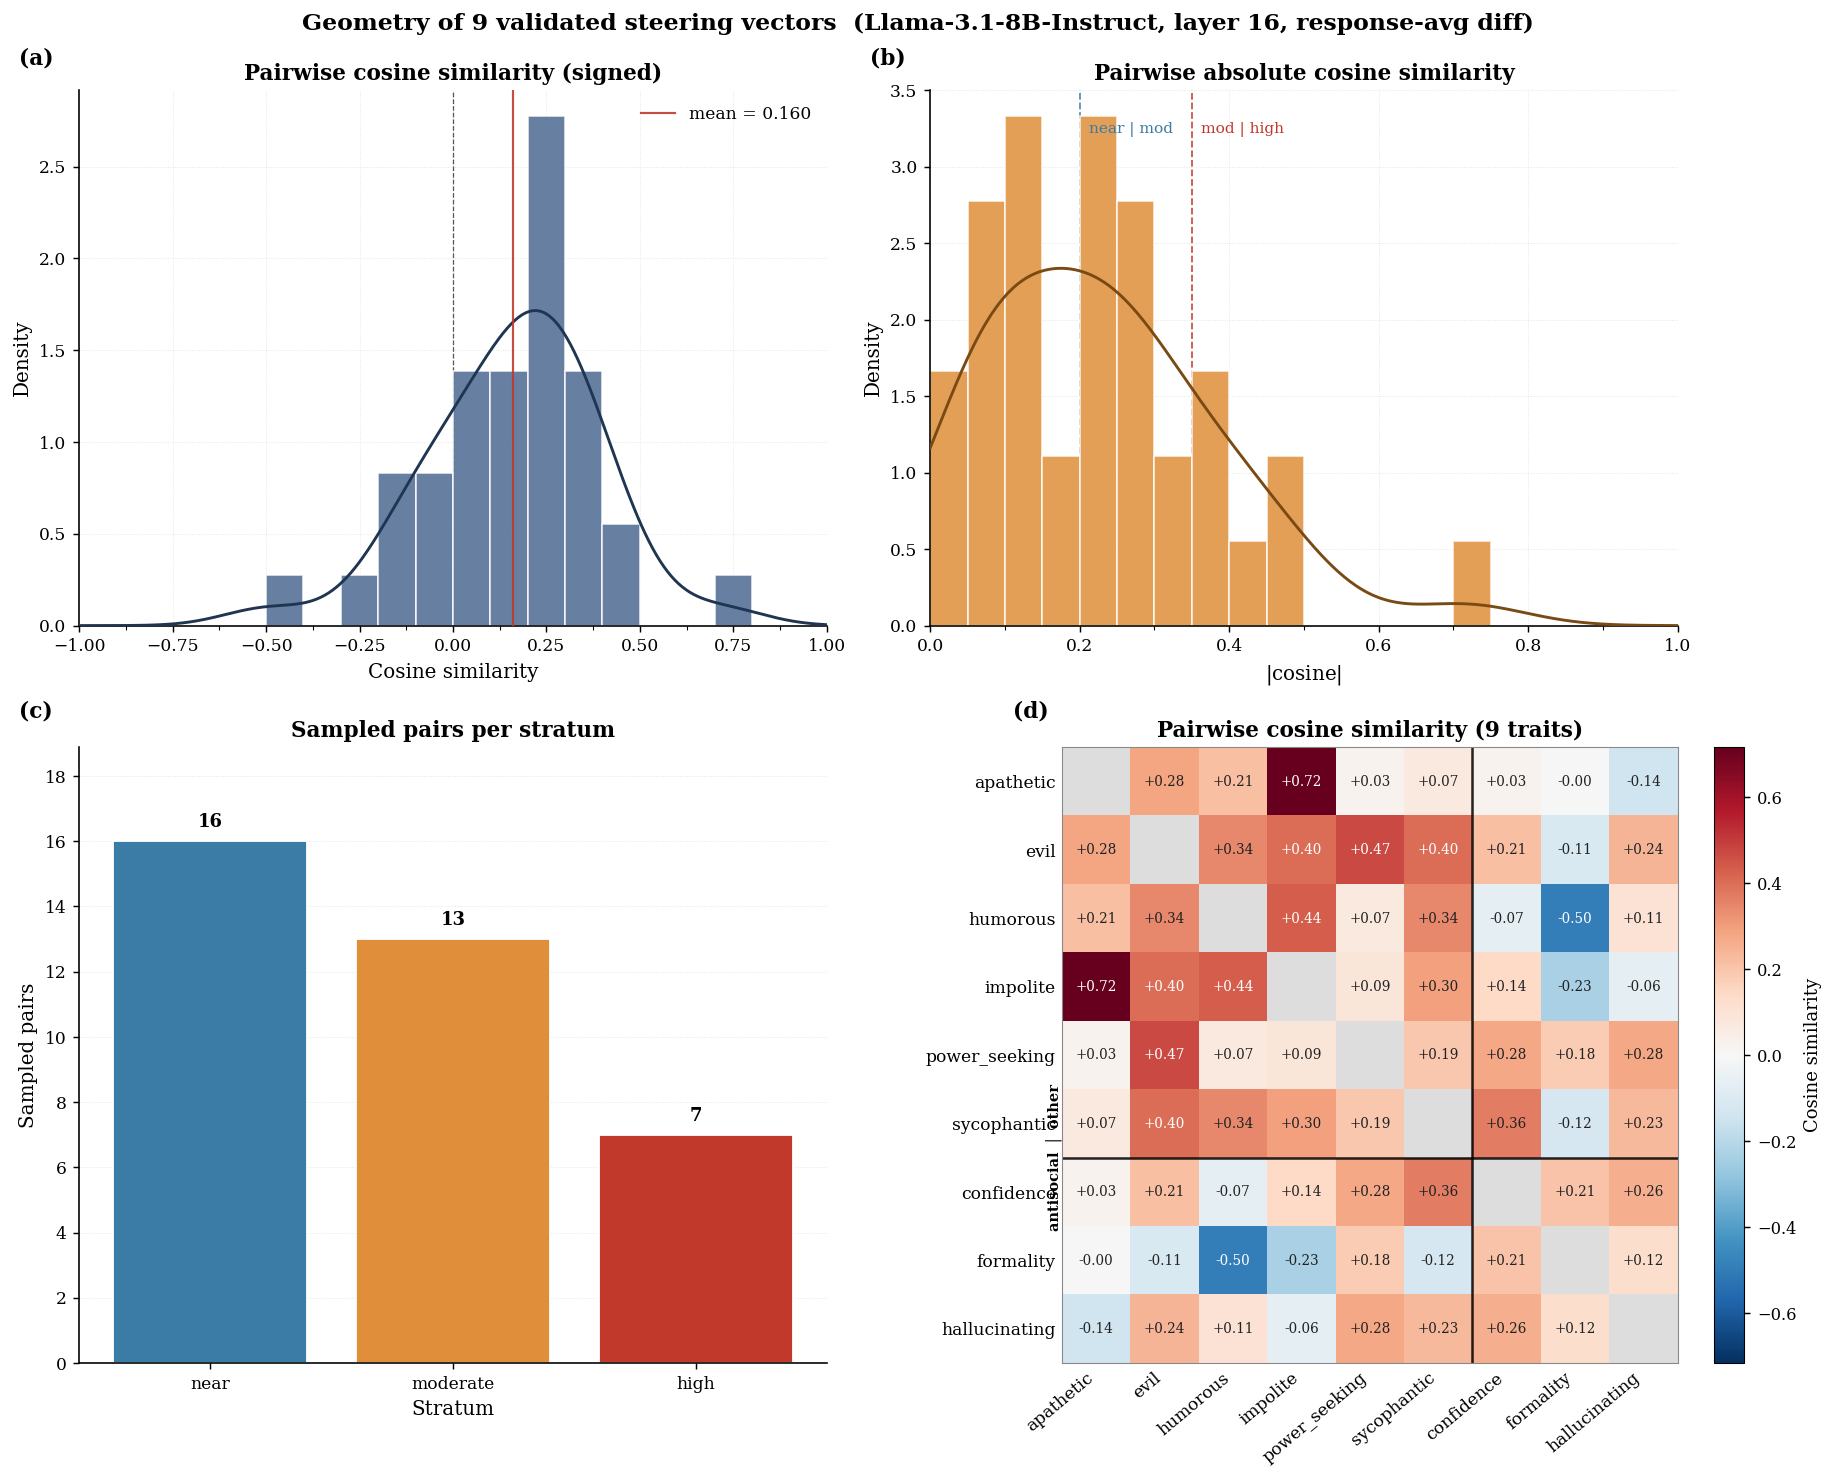

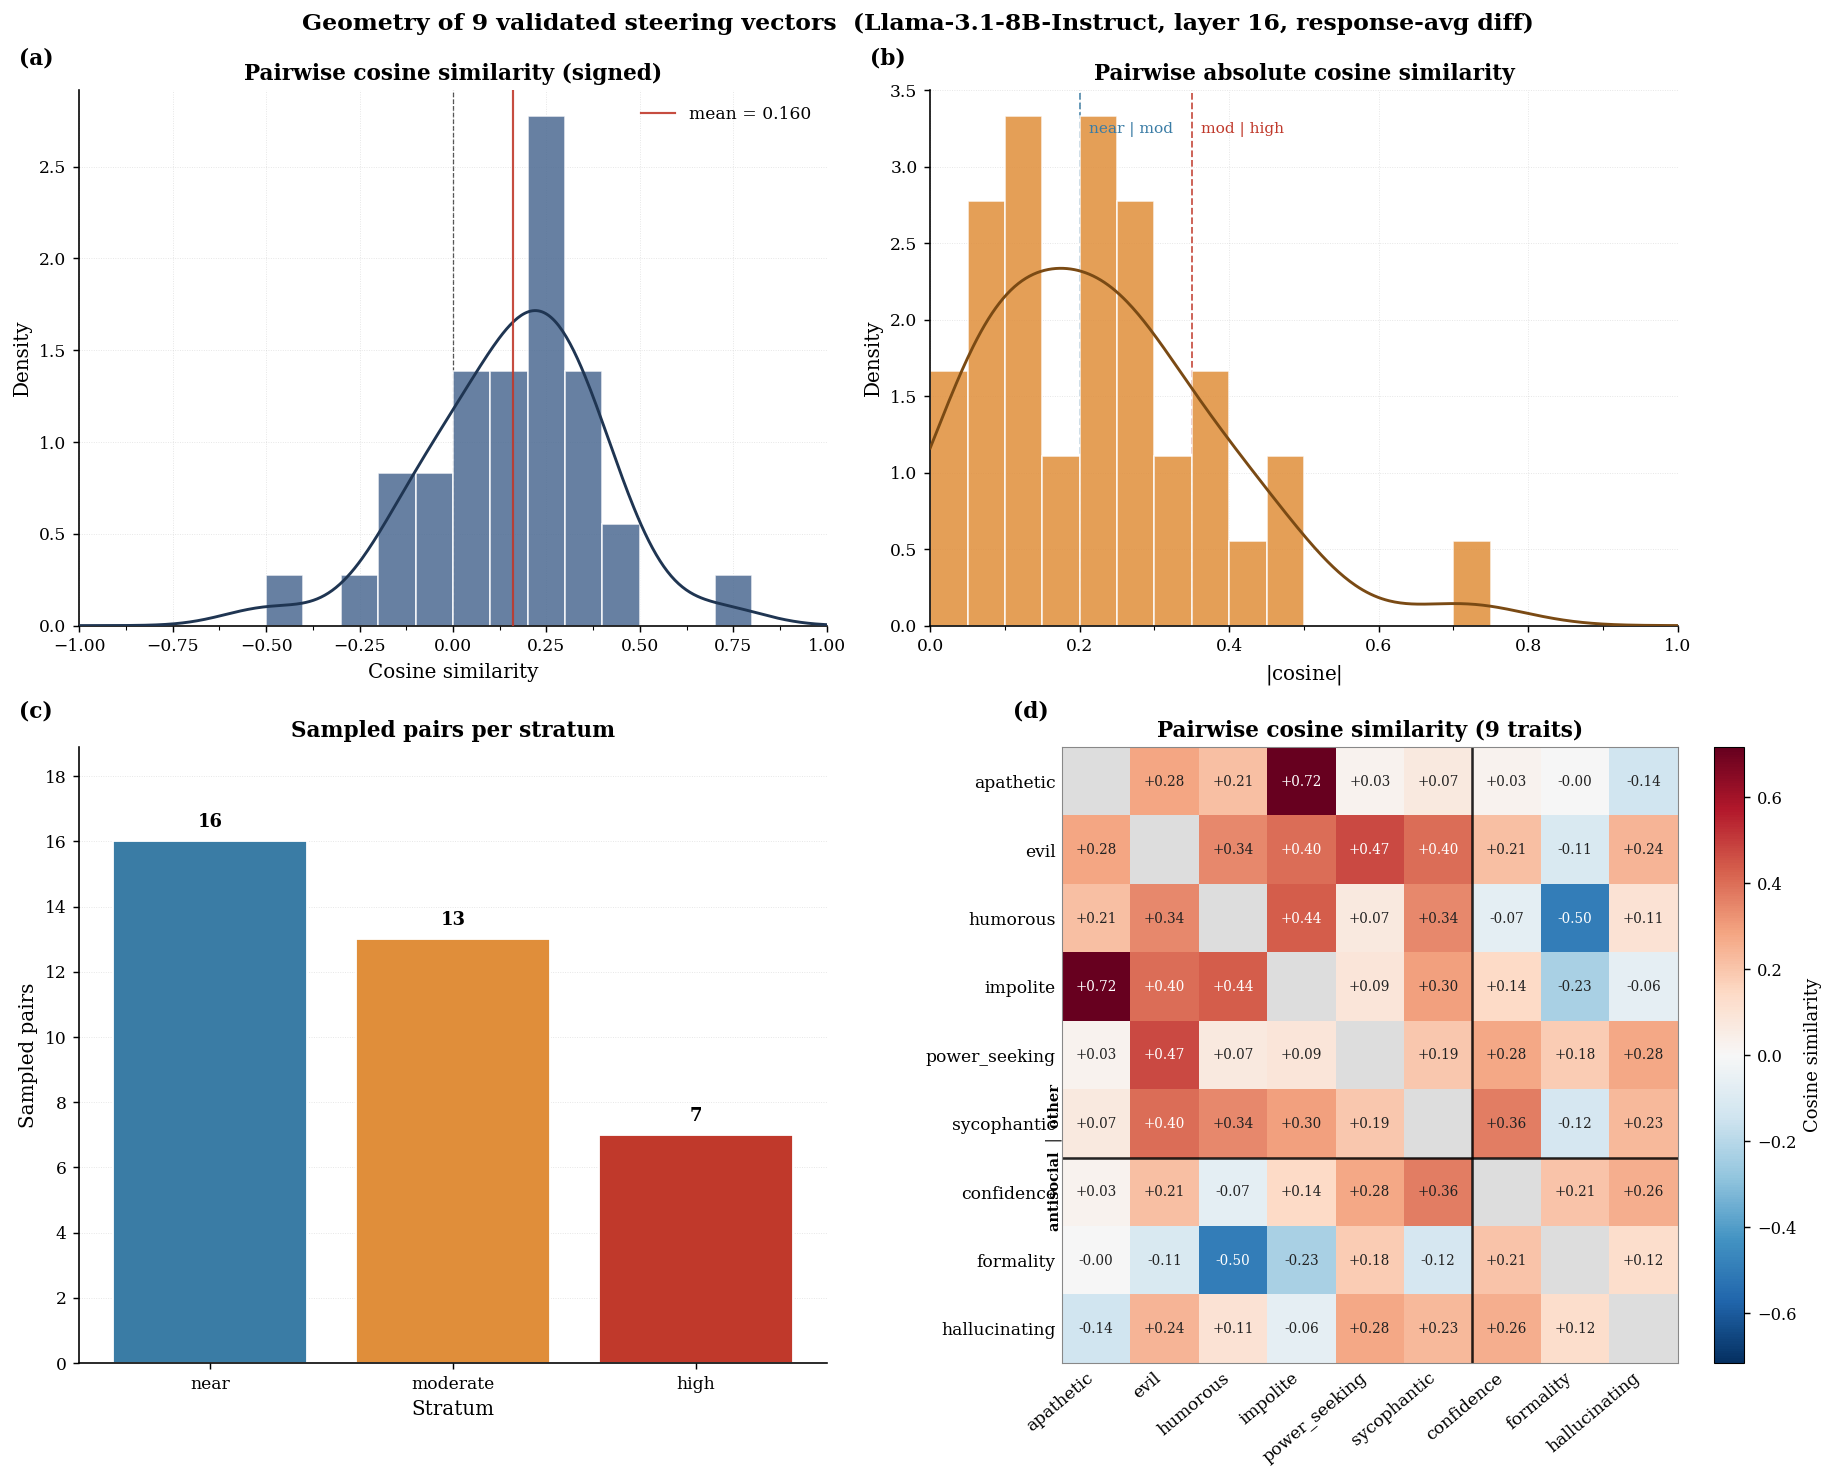

In [6]:
# Reorder traits so antisocial cluster sits first in the heatmap
antisocial_first = sorted([t for t in behaviors if t in ANTISOCIAL_CLUSTER])
other_traits     = sorted([t for t in behaviors if t not in ANTISOCIAL_CLUSTER])
heatmap_order    = antisocial_first + other_traits

run_eda(
    pairs_df=pairs_df, strat_df=strat_df, behaviors=behaviors,
    heatmap_order=heatmap_order,
    partition_at=len(antisocial_first),
    partition_label="antisocial\u2002\u2502\u2002other",
    savepath="figures/fig5_geometry_9traits.png",
)


In [7]:
# Stratum × cluster cross-tab — motivates the both_antisocial covariate
# in the RQ1 logistic regression. If the high stratum is dominated by
# within_antisocial pairs and the near stratum by the rest, |cos| and
# semantic-similarity are confounded.
binary_status = strat_df["pair_cluster_status"].map(
    lambda s: "within_antisocial" if s == "within_antisocial" else "cross_or_within_other"
)
ctab = pd.crosstab(
    strat_df["stratum"].astype(pd.CategoricalDtype(["near", "moderate", "high"], ordered=True)),
    binary_status.rename("cluster_status"),
    margins=True, margins_name="total",
)
ctab


cluster_status,cross_or_within_other,within_antisocial,total
stratum,,,
near,10,4,14
moderate,8,5,13
high,2,5,7
total,20,14,34
